In [1]:
import numpy as np
import matplotlib.pyplot as plt


# VRDU Information Extraction: Efficiency and Representation Analysis
This notebook analyzes the performance and energy efficiency of various models on the VRDU dataset.

**Objectives:**
1. Compare the Pareto efficiency (Energy vs. Accuracy) of Vision models against Text-Only models, factoring in batch size.
2. Evaluate the impact of different document representation strategies (Tesseract, Docling, DeepSeek) on Text-Only model accuracy.

In [2]:
import pandas as pd
import glob

# 1. Define paths for both VRDU and Kleister NDA
paths = [
    "../vrdu_text_only/run_report/*.csv",
    "../vrdu_vision_v2/run_report/*.csv",
    "../kleister_nda/run_report/*.csv",
    "../kleister_nda_vl_v2/run_report/*.csv"
]

all_files = []
for path in paths:
    all_files.extend(glob.glob(path))

# 2. Extract Data
data_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file)

        model_name = df_temp['model_name'].iloc[0]
        accuracy = df_temp['avg_field_em'].iloc[0] * 100
        energy = df_temp['total_energy_wh'].iloc[0]
        batch_size = df_temp['batch_size'].iloc[0] if 'batch_size' in df_temp.columns else 1

        # Extract backend
        backend = df_temp['backend'].iloc[0] if 'backend' in df_temp.columns else "default"

        # Determine Dataset based on file path
        dataset = "VRDU" if "vrdu" in file else "Kleister NDA"

        # Determine Modality based on file path
        if "vrdu_vision" in file or "kleister_nda_vl" in file:
            modality = "Vision"
        else:
            modality = "Text-Only"

        # FORCED INFERENCE: Determine Task / OCR Strategy based strictly on folder path
        if "deepseek" in file:
            task = "deepseek"
        elif "docling" in file:
            task = "docling"
        elif "tesseract" in file:
            task = "tesseract"
        elif modality == "Vision":
            task = "vision"
        elif "vrdu_text_only" in file:
            task = "default"
        else:
            task = df_temp['task'].iloc[0] if 'task' in df_temp.columns else "default"

        data_list.append({
            'Dataset': dataset,
            'Model': model_name,
            'Batch_Size': batch_size,
            'Accuracy': accuracy,
            'Energy_Wh': energy,
            'Modality': modality,
            'Task': task,
            'Backend': backend
        })
    except Exception as e:
        print(f"Error reading {file}: {e}")

df_all = pd.DataFrame(data_list)

if not df_all.empty:
    # Merge 'vllm' and 'vllm-vl' into a single backend category
    df_all['Backend'] = df_all['Backend'].replace('vllm-vl', 'vllm')

    # Ensure Batch_Size is numeric for downstream sorting/plotting
    df_all['Batch_Size'] = pd.to_numeric(df_all['Batch_Size']).fillna(1)

print(f"Successfully loaded {len(df_all)} experiment runs.")

Successfully loaded 266 experiment runs.


## 1. Modality Efficiency: Vision vs. Text-Only
This section isolates the best performing runs per model and batch size, then calculates two distinct Pareto frontiers to see the efficiency ceiling of each modality. Marker sizes indicate the batch size used.

NameError: name 'adjust_text' is not defined

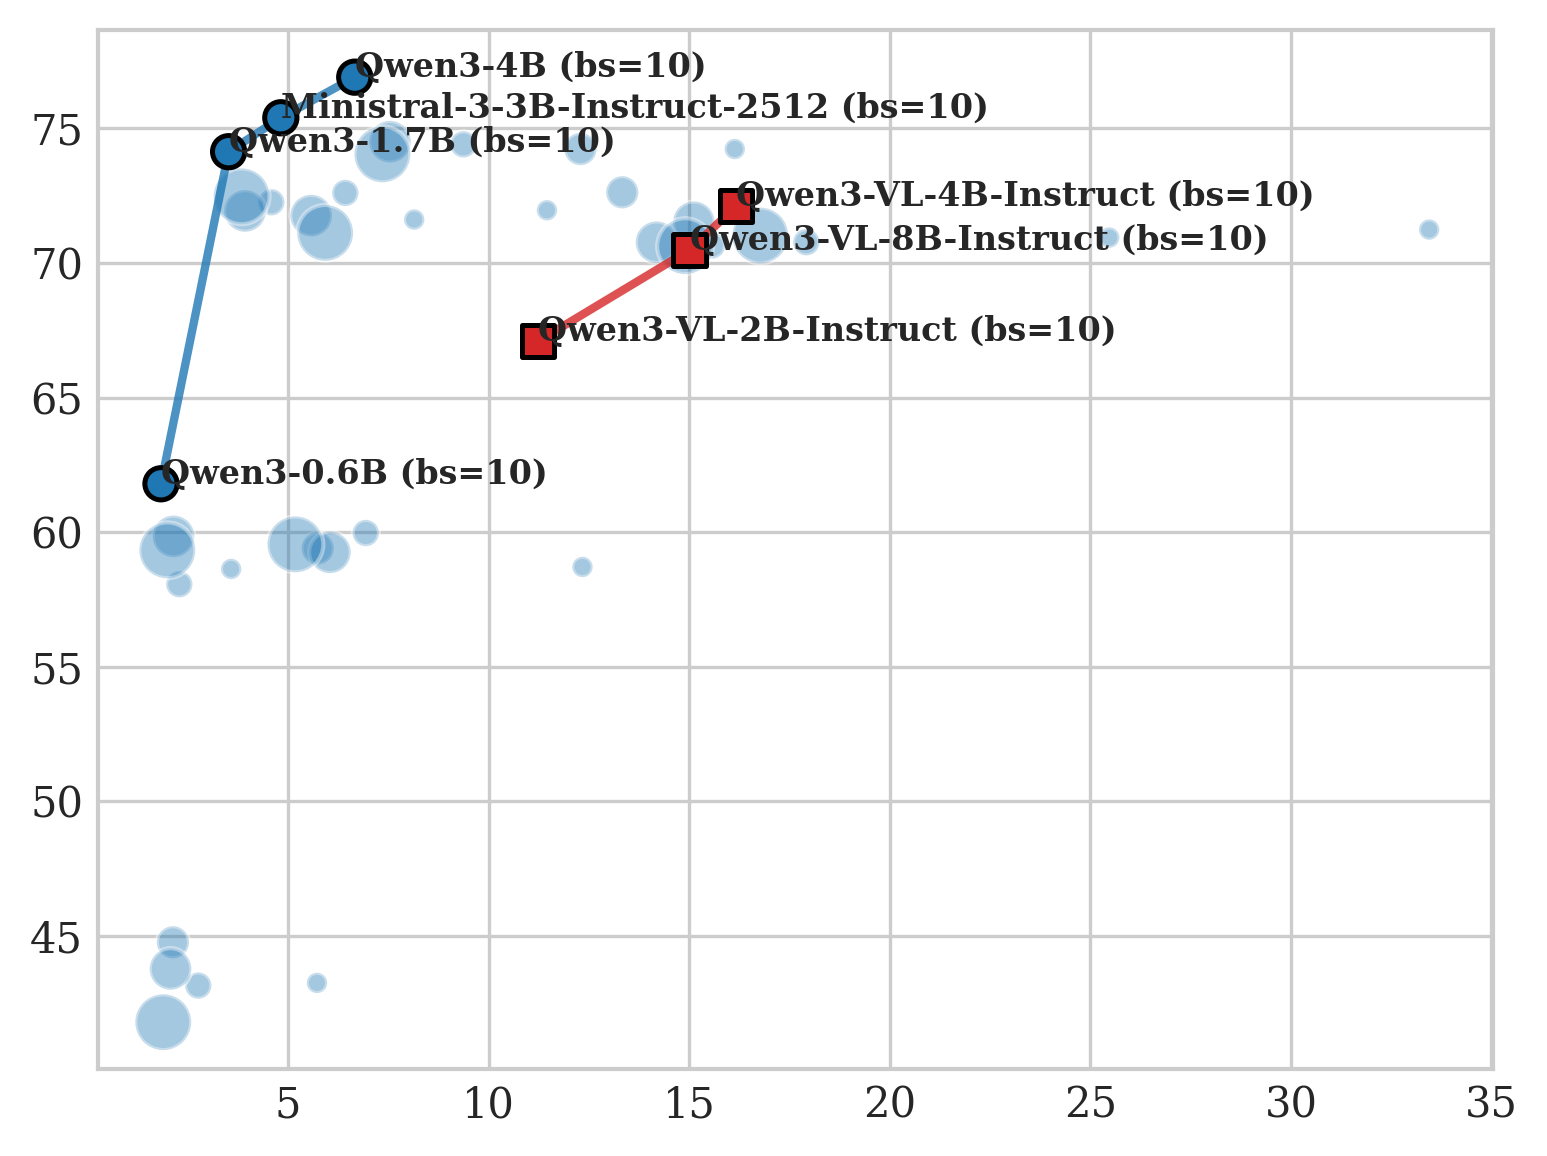

In [3]:
# 1. Filter for best runs per Model + Batch Size combo
df_sorted = df_all.sort_values(by=['Model', 'Batch_Size', 'Accuracy', 'Energy_Wh'], ascending=[True, True, False, True])
df_pareto_base = df_sorted.drop_duplicates(subset=['Model', 'Batch_Size'], keep='first').reset_index(drop=True)

# 2. Calculate Separate Pareto Frontiers per Modality
pareto_data = {}
for modality in df_pareto_base['Modality'].unique():
    subset = df_pareto_base[df_pareto_base['Modality'] == modality].sort_values('Energy_Wh').reset_index(drop=True)

    px, py, pm, pbs = [], [], [], []
    max_acc = -1

    for index, row in subset.iterrows():
        if row['Accuracy'] > max_acc:
            px.append(row['Energy_Wh'])
            py.append(row['Accuracy'])
            pm.append(row['Model'])
            pbs.append(row['Batch_Size'])
            max_acc = row['Accuracy']

    pareto_data[modality] = {'x': px, 'y': py, 'models': pm, 'bs': pbs}

# 3. Plotting Setup (ACL Formatting)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.figsize': (6.0, 4.5),
    'figure.dpi': 300
})

fig, ax = plt.subplots()
colors = {'Text-Only': '#1f77b4', 'Vision': '#d62728'}
markers = {'Text-Only': 'o', 'Vision': 's'}
texts = []

# 4. Plot Points and Frontiers
for modality in df_pareto_base['Modality'].unique():
    subset = df_pareto_base[df_pareto_base['Modality'] == modality]
    p_models = pareto_data[modality]['models']
    is_pareto = subset['Model'].isin(p_models)

    # Scale marker size by batch size
    sizes = 20 + (subset['Batch_Size'] * 4)

    # Plot all sub-optimal points
    ax.scatter(subset['Energy_Wh'], subset['Accuracy'],
               s=sizes, c=colors[modality], marker=markers[modality],
               edgecolors='white', alpha=0.4, zorder=2, label=f"{modality} (All)")

    # Highlight Pareto points and draw lines
    p_x = pareto_data[modality]['x']
    p_y = pareto_data[modality]['y']

    ax.plot(p_x, p_y, '-', color=colors[modality], linewidth=2, alpha=0.8, zorder=3, label=f'{modality} Frontier')
    ax.scatter(p_x, p_y, s=[20 + (bs * 4) for bs in pareto_data[modality]['bs']],
               c=colors[modality], marker=markers[modality], edgecolors='black', linewidths=1.2, alpha=1.0, zorder=4)

    # Annotate Pareto points
    for i in range(len(p_x)):
        label = f"{p_models[i]} (bs={int(pareto_data[modality]['bs'][i])})"
        texts.append(ax.text(p_x[i], p_y[i], label, fontsize=8, fontweight='bold', zorder=5))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.8), ax=ax)

ax.set_xscale('log')
ax.set_xlabel('Energy (Wh) - Log Scale\n(Marker size indicates Batch Size)')
ax.set_ylabel('Avg Field Exact Match (%)')
ax.set_title('Efficiency Frontier: Text-Only vs. Vision Models', pad=10)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower right', frameon=True, shadow=True, fontsize=8)

plt.tight_layout()
plt.savefig('acl_dual_pareto.pdf', format='pdf', bbox_inches='tight')
plt.show()

## 2. Text-Only Input Strategies
This section isolates the text-only models to compare the extraction exact match scores across three text representation pipelines: Tesseract (Baseline), Docling, and DeepSeek.

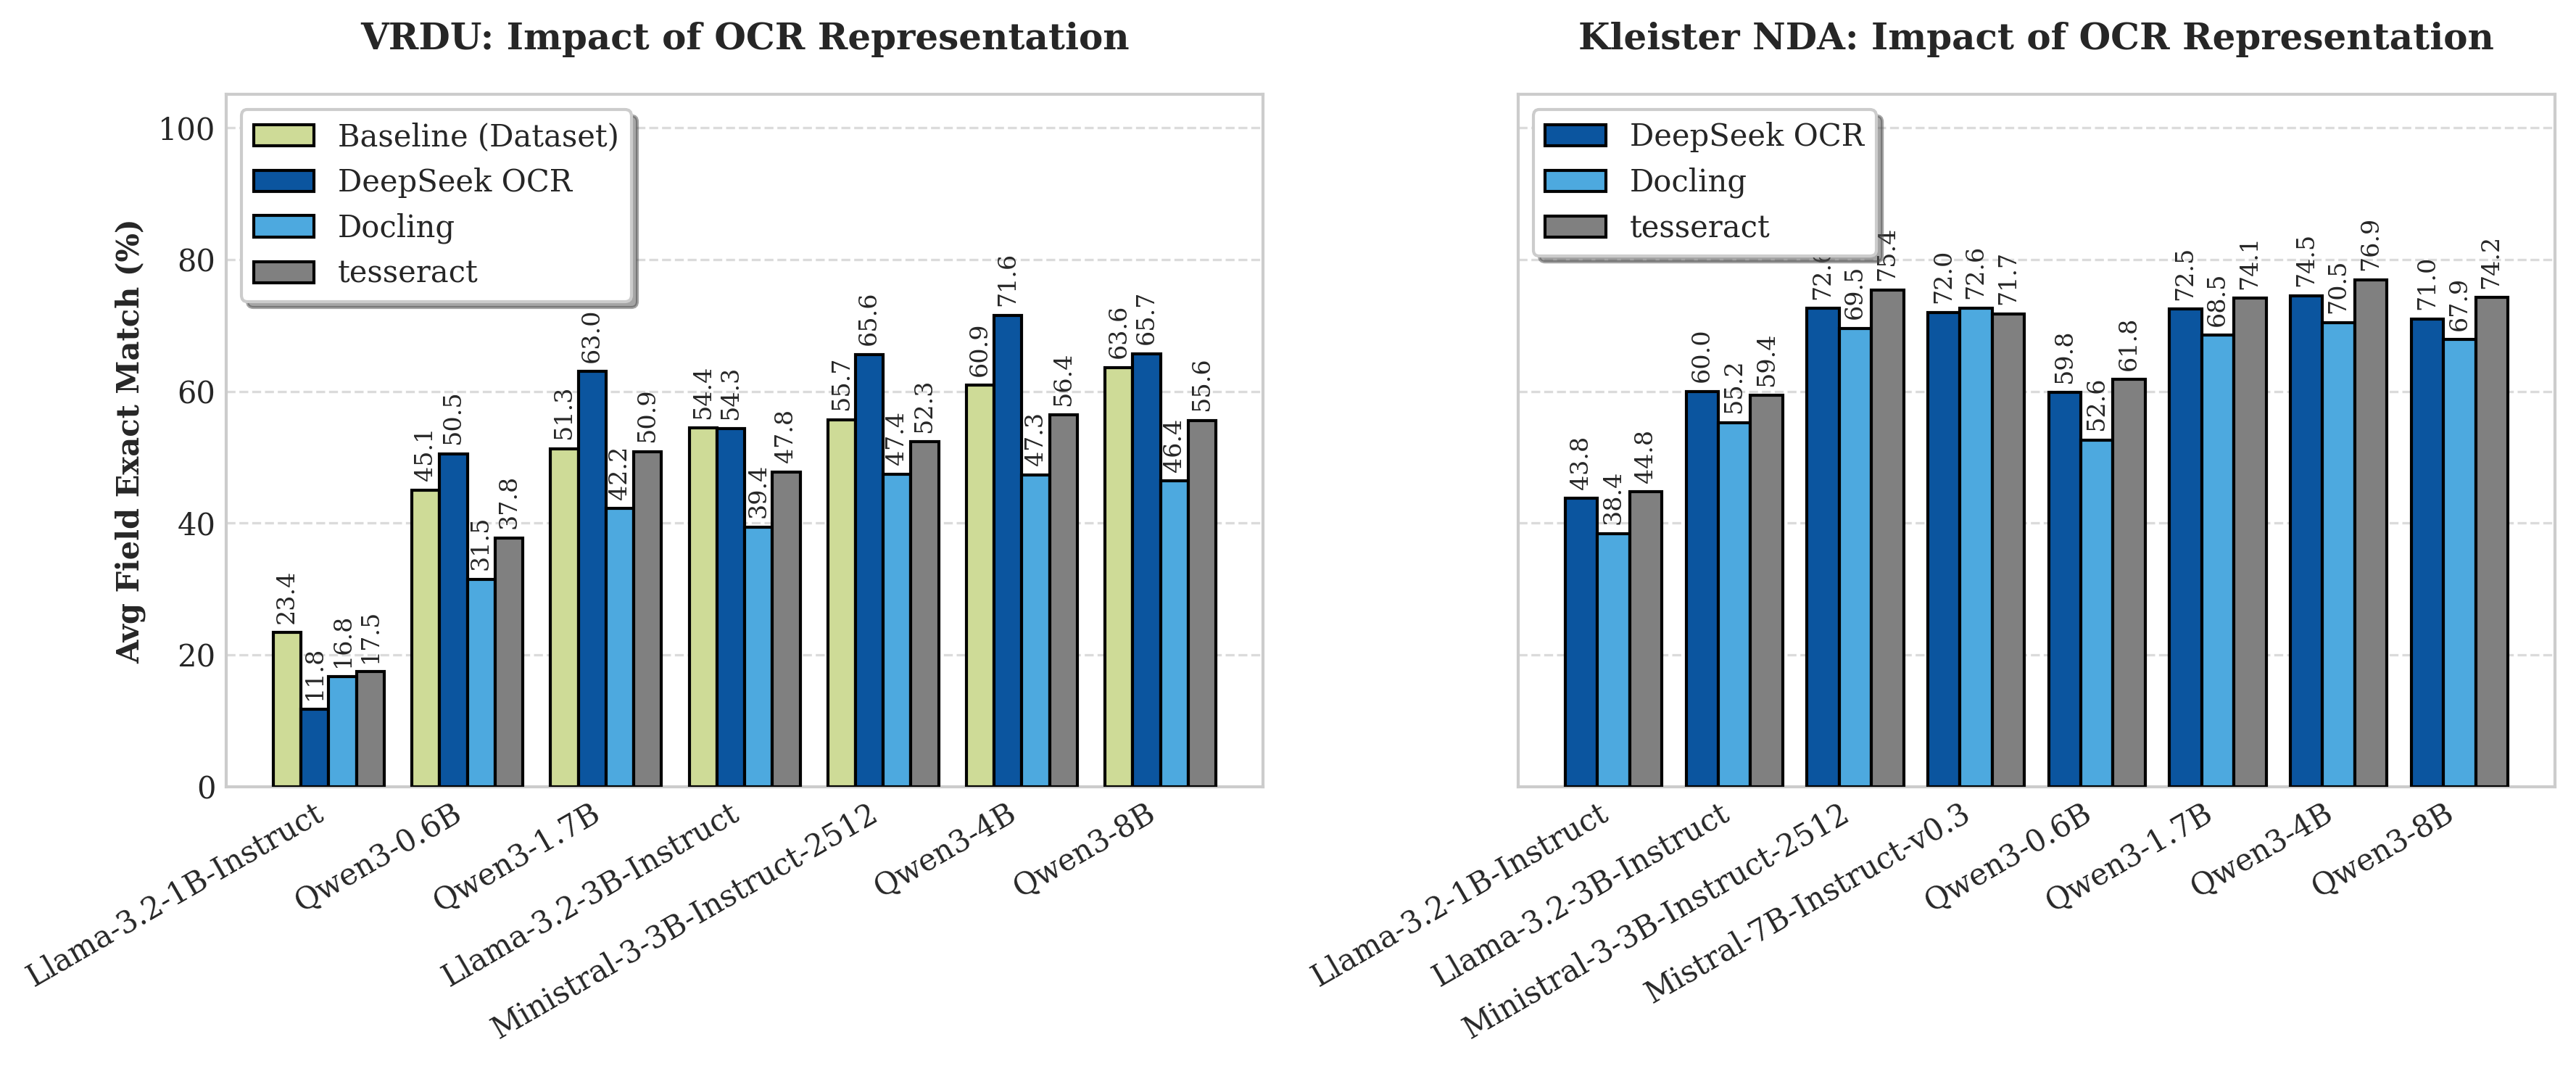

In [4]:

# 1. Map the raw task names to clean, uniform labels for plotting
task_mapping = {
    'vrdu_default': 'Baseline (Dataset)',
    'default': 'Baseline (Dataset)',
    'vrdu_docling': 'Docling',
    'docling': 'Docling',
    'vrdu_deepseek': 'DeepSeek OCR',
    'deepseek': 'DeepSeek OCR'
}

# Apply mapping to a new column
df_all['Task_Clean'] = df_all['Task'].map(lambda x: task_mapping.get(x, x))

# Standard colors for the OCR strategies to keep consistency across plots
ocr_colors = {
    'Baseline (Dataset)': '#cedb97',
    'Docling': '#4da9df',
    'DeepSeek OCR': '#0b559f'
}

# 2. Plotting Setup (1 row, 2 columns)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.figsize': (12.0, 5.0), # Wider figure to fit both datasets
    'figure.dpi': 300
})

fig, axes = plt.subplots(1, 2, sharey=True)

datasets = ['VRDU', 'Kleister NDA']

# 3. Loop through datasets and create a subplot for each
for i, dataset_name in enumerate(datasets):
    ax = axes[i]

    # Filter for Text-Only models and the current dataset
    df_text = df_all[(df_all['Modality'] == 'Text-Only') & (df_all['Dataset'] == dataset_name)].copy()

    # If the dataset is empty (e.g., misspelled name), skip
    if df_text.empty:
        ax.set_title(f'{dataset_name} (No Data)')
        continue

    # Keep best accuracy per Model + Task combination
    df_text_best = df_text.sort_values(by=['Model', 'Task_Clean', 'Accuracy'], ascending=[True, True, False])
    df_text_best = df_text_best.drop_duplicates(subset=['Model', 'Task_Clean'], keep='first').reset_index(drop=True)

    # Pivot data for grouped bar chart
    pivot_df = df_text_best.pivot(index='Model', columns='Task_Clean', values='Accuracy').fillna(0)

    # Sort models alphabetically or by a specific column if it exists
    if 'Baseline (Dataset)' in pivot_df.columns:
        pivot_df = pivot_df.sort_values('Baseline (Dataset)', ascending=True)
    else:
        pivot_df = pivot_df.sort_index()

    # Determine bar positions
    x = np.arange(len(pivot_df.index))
    num_tasks = len(pivot_df.columns)
    width = 0.8 / num_tasks # Dynamic width based on number of OCR strategies

    # Plot each OCR strategy
    for j, task_name in enumerate(pivot_df.columns):
        # Calculate offset for grouped bars
        offset = (j - num_tasks/2) * width + (width/2)

        # Fixed the '#gray' typo here!
        color = ocr_colors.get(task_name, 'gray')
        rects = ax.bar(x + offset, pivot_df[task_name], width, label=task_name, color=color, edgecolor='black', zorder=3)

        # Add value labels on top of the bars
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8, rotation=90)

    # Formatting
    ax.set_title(f'{dataset_name}: Impact of OCR Representation', pad=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=30, ha='right')
    ax.set_ylim(0, 105)

    if i == 0:
        ax.set_ylabel('Avg Field Exact Match (%)', fontweight='bold')

    ax.legend(loc='upper left', frameon=True, shadow=True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
    ax.grid(False, axis='x')

plt.tight_layout()
plt.savefig('acl_text_tasks_comparison_both_datasets.pdf', format='pdf', bbox_inches='tight')
plt.show()

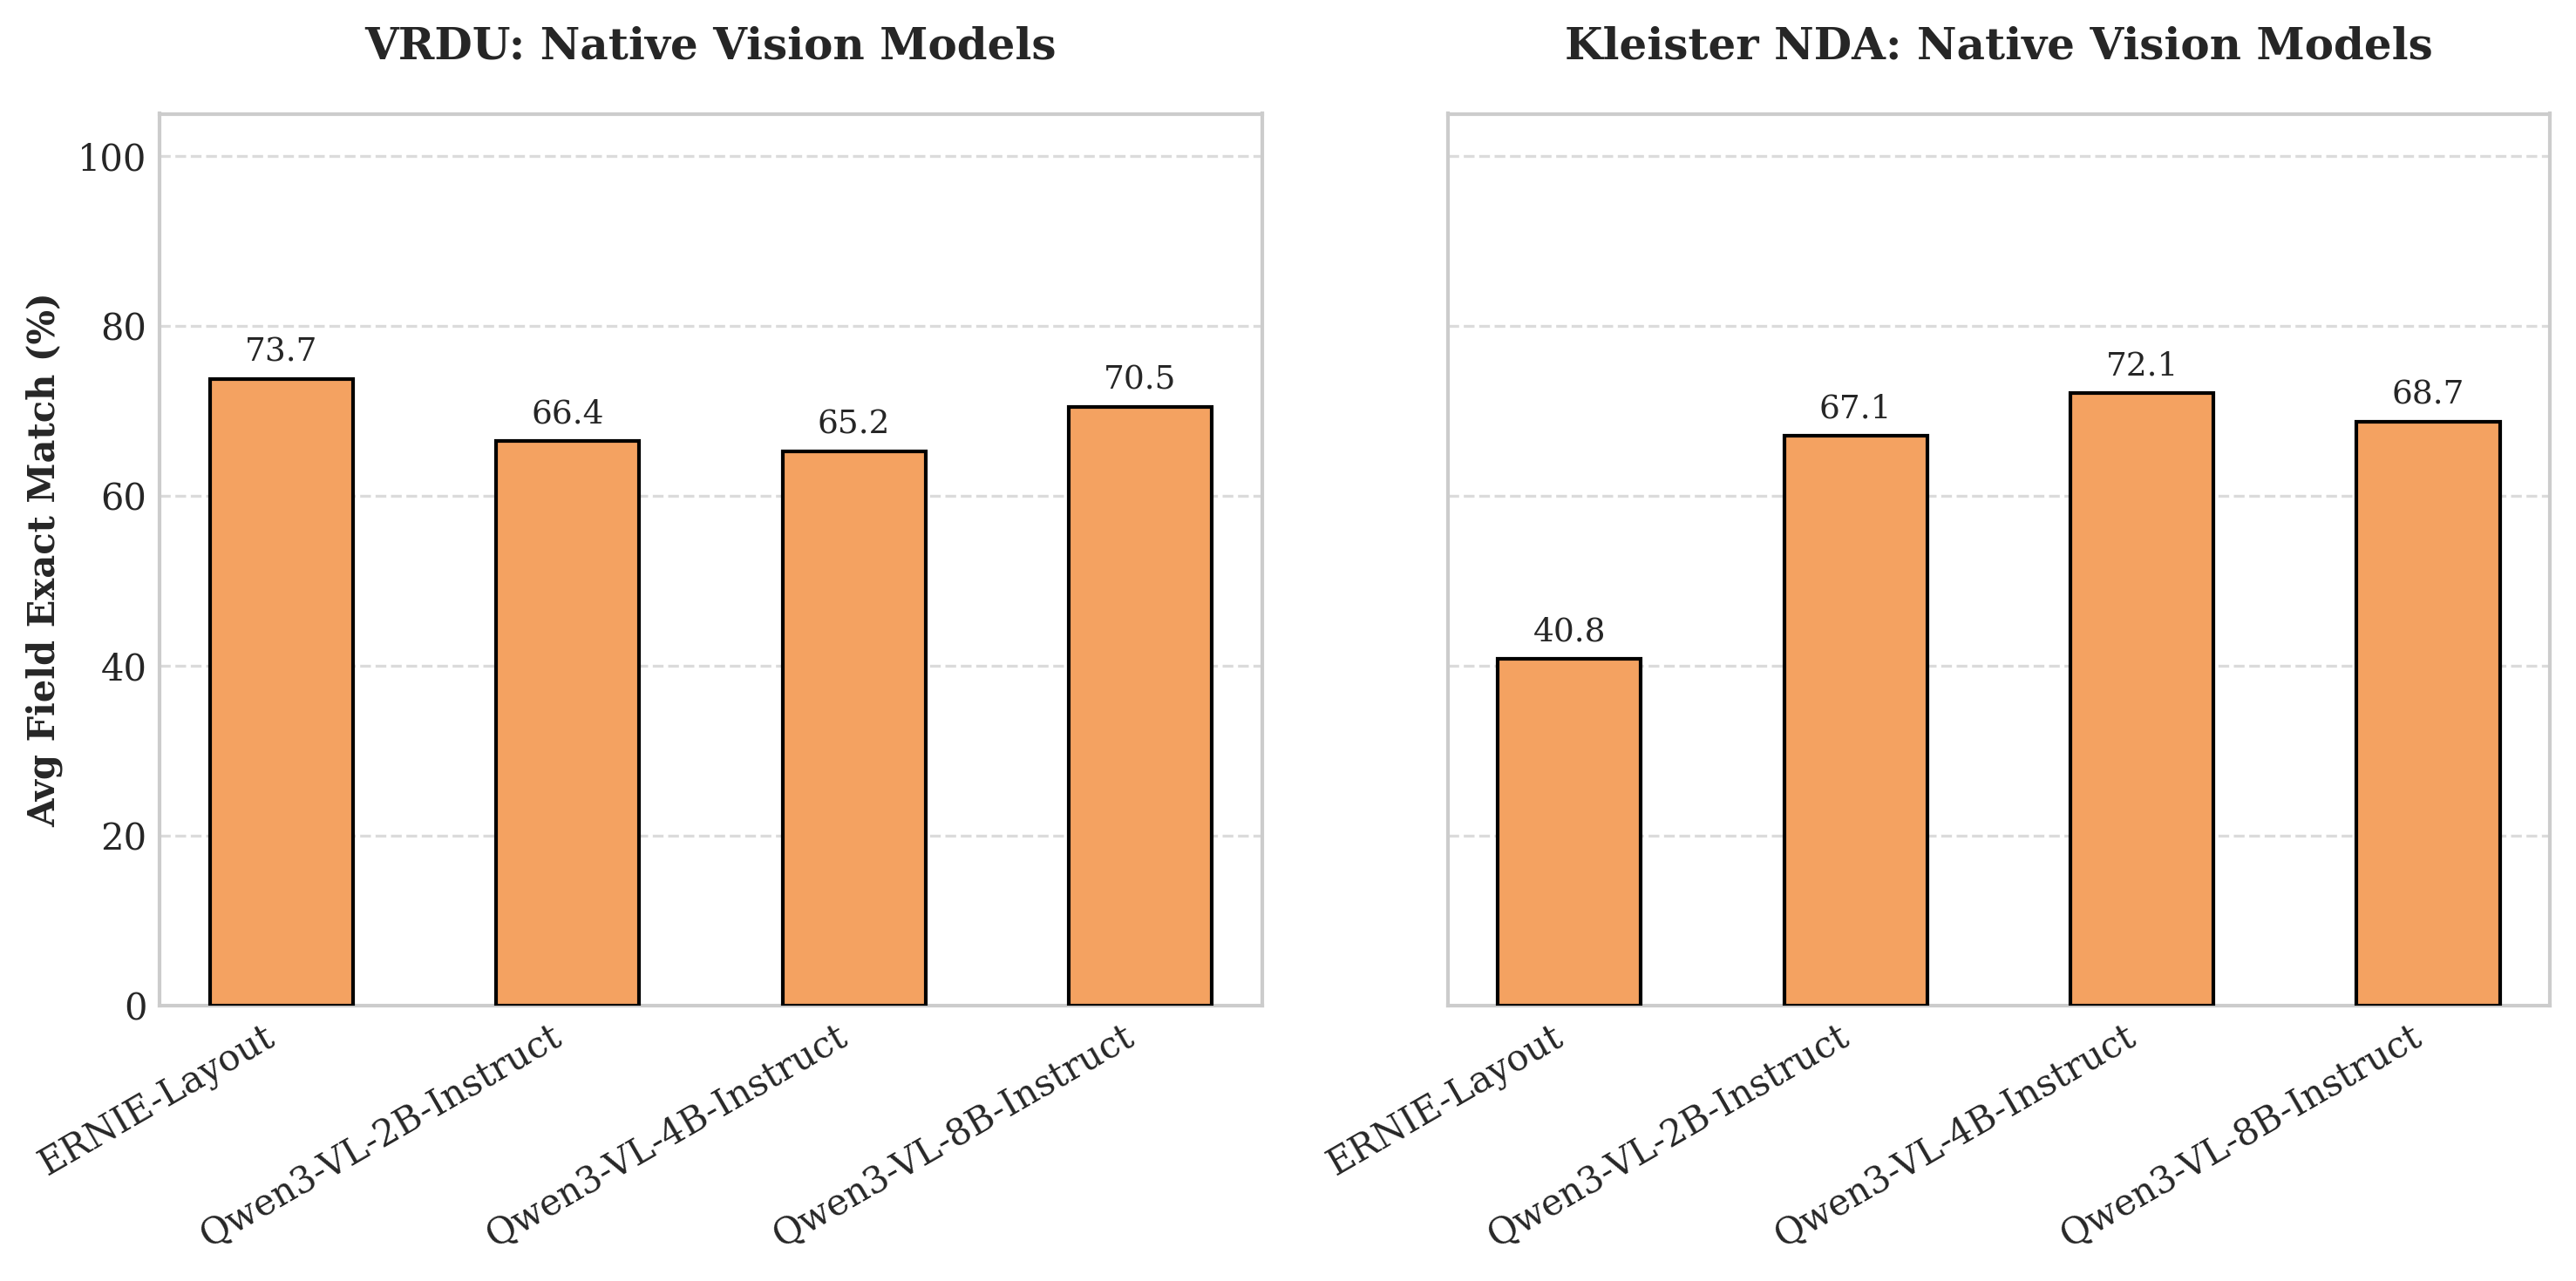

In [5]:
# 1. Load VRDU Results
ernie_vrdu_path = '../benchmark/ernie-layout/vrdu_ernie_summary.csv'
ernie_vrdu_df = pd.read_csv(ernie_vrdu_path)
ernie_vrdu_accuracy = ernie_vrdu_df['average_field_em'].iloc[0] * 100

new_vrdu_row = pd.DataFrame([{
    'Model': 'ERNIE-Layout',
    'Dataset': 'VRDU',
    'Modality': 'Vision',
    'Accuracy': ernie_vrdu_accuracy
}])

# 2. Load Kleister NDA Results (New Addition)
ernie_kleister_path = '../benchmark/ernie-layout/kleister_summary_results.csv'
ernie_kleister_df = pd.read_csv(ernie_kleister_path)
ernie_kleister_accuracy = ernie_kleister_df['average_field_em'].iloc[0] * 100

new_kleister_row = pd.DataFrame([{
    'Model': 'ERNIE-Layout',
    'Dataset': 'Kleister NDA',
    'Modality': 'Vision',
    'Accuracy': ernie_kleister_accuracy
}])

# 3. Append both rows to df_all
# (Assuming df_all is already defined earlier in your environment)
df_all = pd.concat([df_all, new_vrdu_row, new_kleister_row], ignore_index=True)

# --- Plotting Setup (1 row, 2 columns) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.figsize': (10.0, 5.0), # Sized perfectly for 2 subplots
    'figure.dpi': 300
})

fig, axes = plt.subplots(1, 2, sharey=True)

datasets = ['VRDU', 'Kleister NDA']

# We can use a consistent color for the vision models
vision_color = '#f4a261' # Orange to differentiate from the blue/green OCR text models

# --- Loop through datasets and create a subplot for each ---
for i, dataset_name in enumerate(datasets):
    ax = axes[i]

    # Filter for Vision models and the current dataset
    df_vision = df_all[(df_all['Modality'] == 'Vision') & (df_all['Dataset'] == dataset_name)].copy()

    # If the dataset is empty, skip
    if df_vision.empty:
        ax.set_title(f'{dataset_name} (No Data)')
        continue

    # Keep best accuracy per Model
    df_vision_best = df_vision.sort_values(by=['Model', 'Accuracy'], ascending=[True, False])
    df_vision_best = df_vision_best.drop_duplicates(subset=['Model'], keep='first').reset_index(drop=True)

    # Sort models alphabetically
    df_vision_best = df_vision_best.sort_values('Model')

    # Determine bar positions
    x = np.arange(len(df_vision_best['Model']))
    width = 0.5

    # Plot the bars
    rects = ax.bar(x, df_vision_best['Accuracy'], width, color=vision_color, edgecolor='black', zorder=3)

    # Add value labels on top of the bars
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    # Formatting
    ax.set_title(f'{dataset_name}: Native Vision Models', pad=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_vision_best['Model'], rotation=30, ha='right')
    ax.set_ylim(0, 105)

    if i == 0:
        ax.set_ylabel('Avg Field Exact Match (%)', fontweight='bold')

    ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
    ax.grid(False, axis='x')

plt.tight_layout()
plt.savefig('acl_vision_models_both_datasets.pdf', format='pdf', bbox_inches='tight')
plt.show()

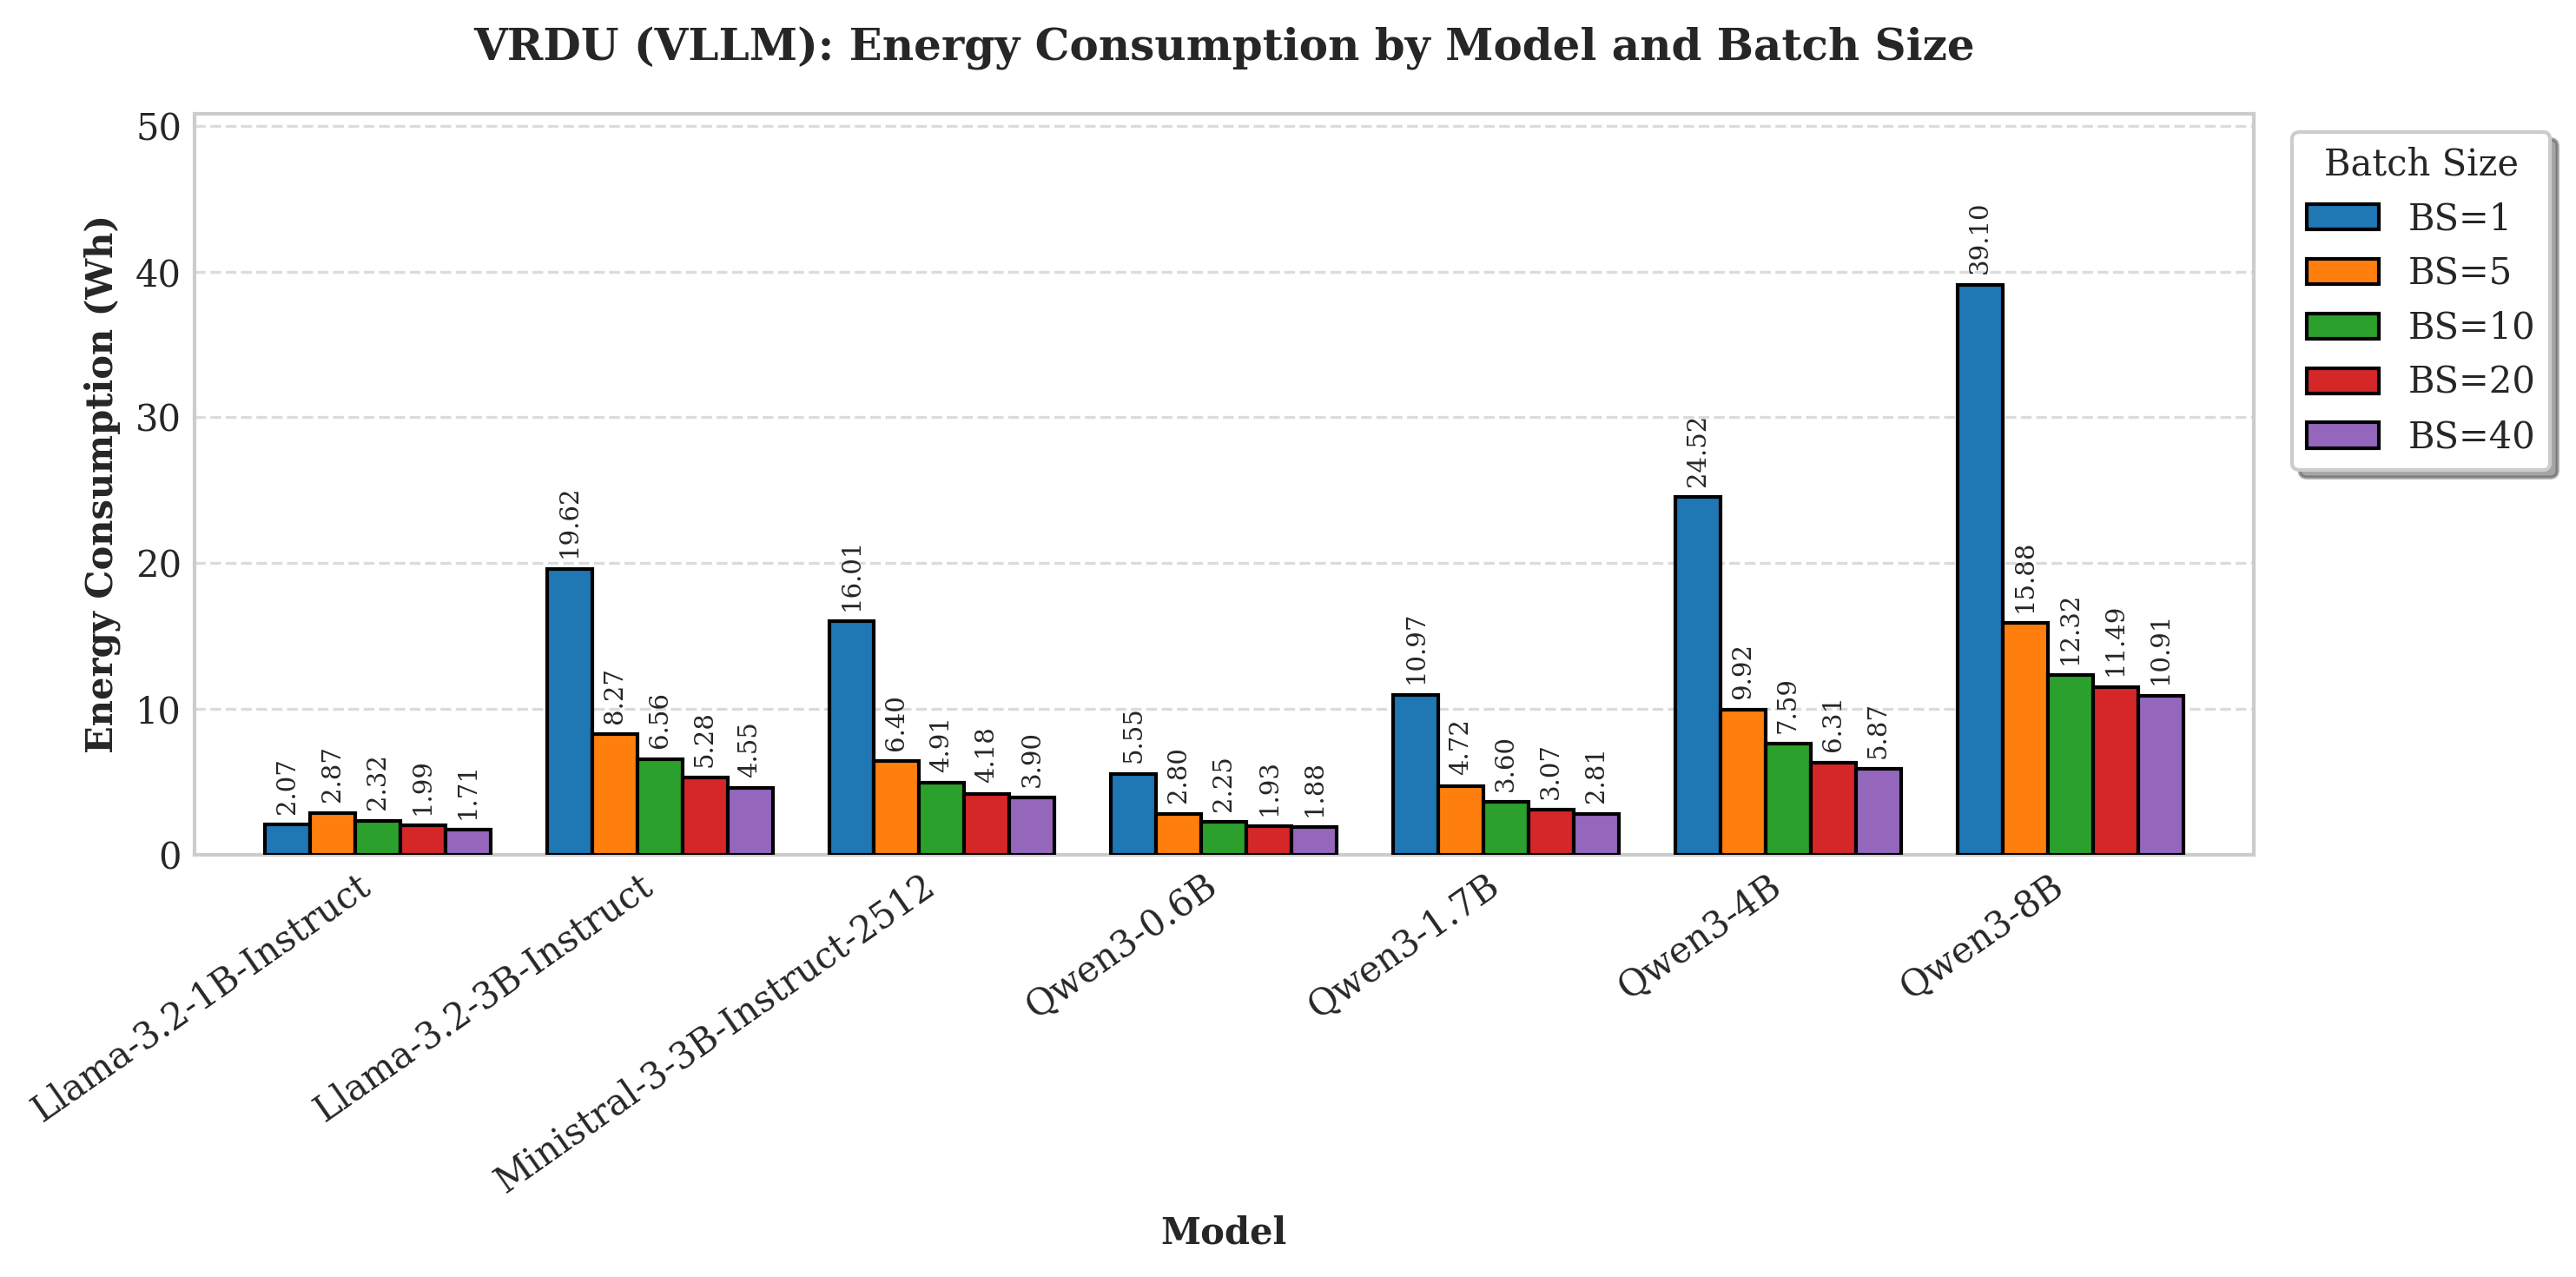

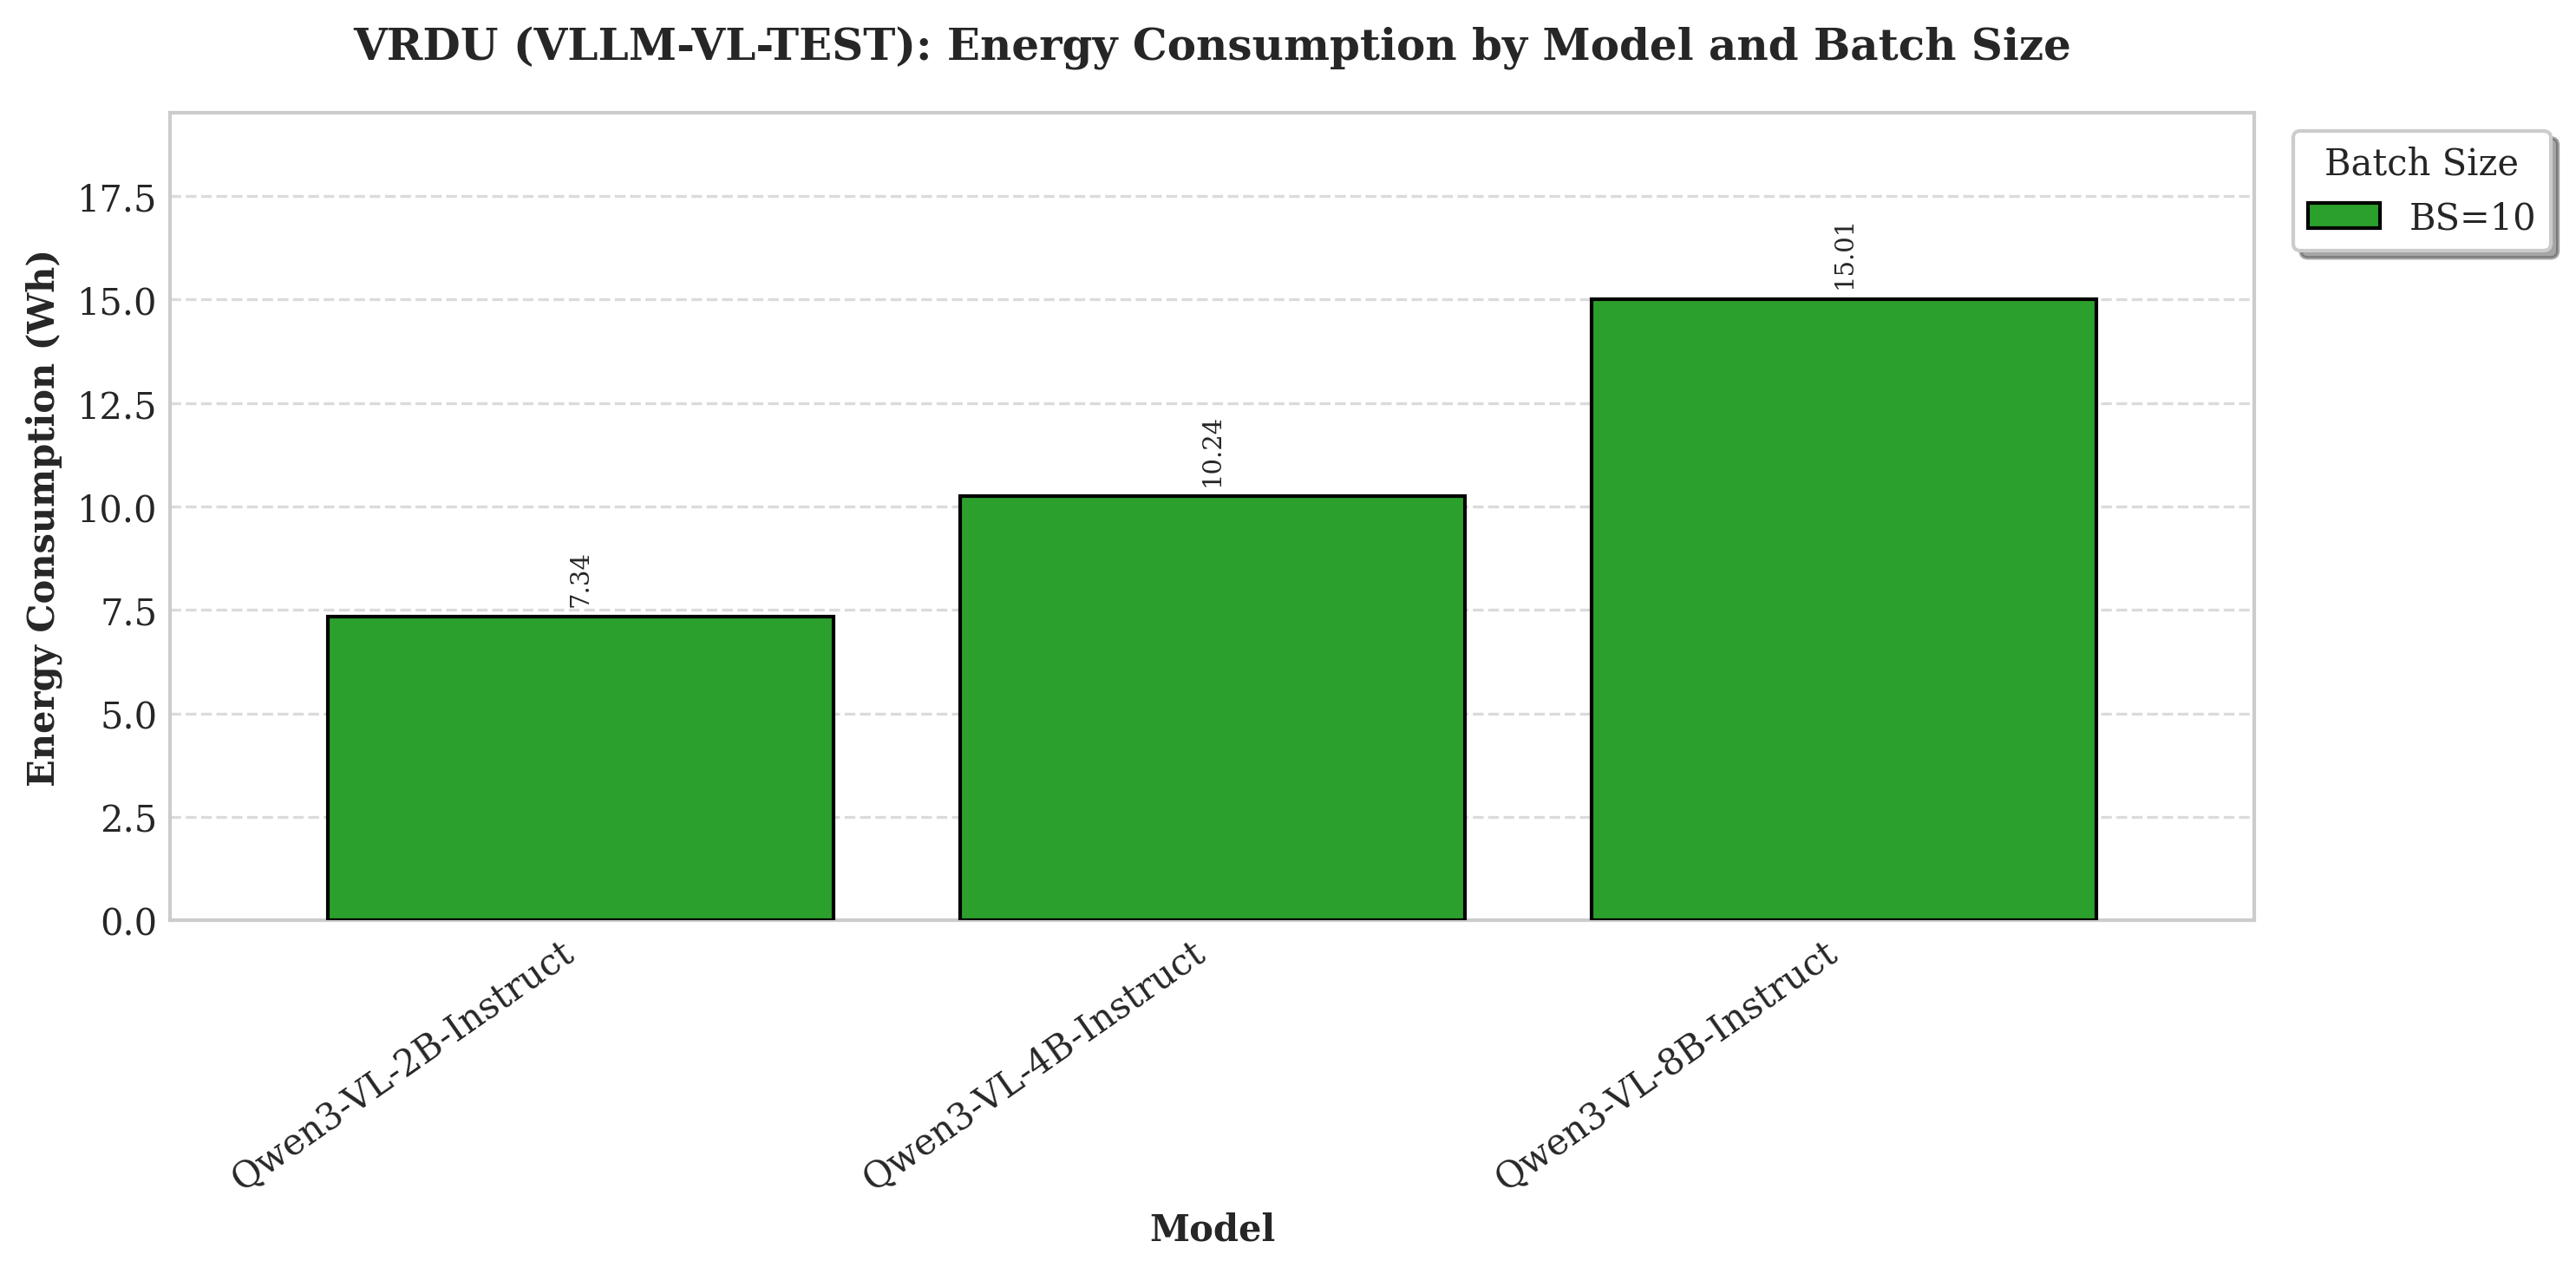

No data available for VRDU with backend sglang
No data available for VRDU with backend nan


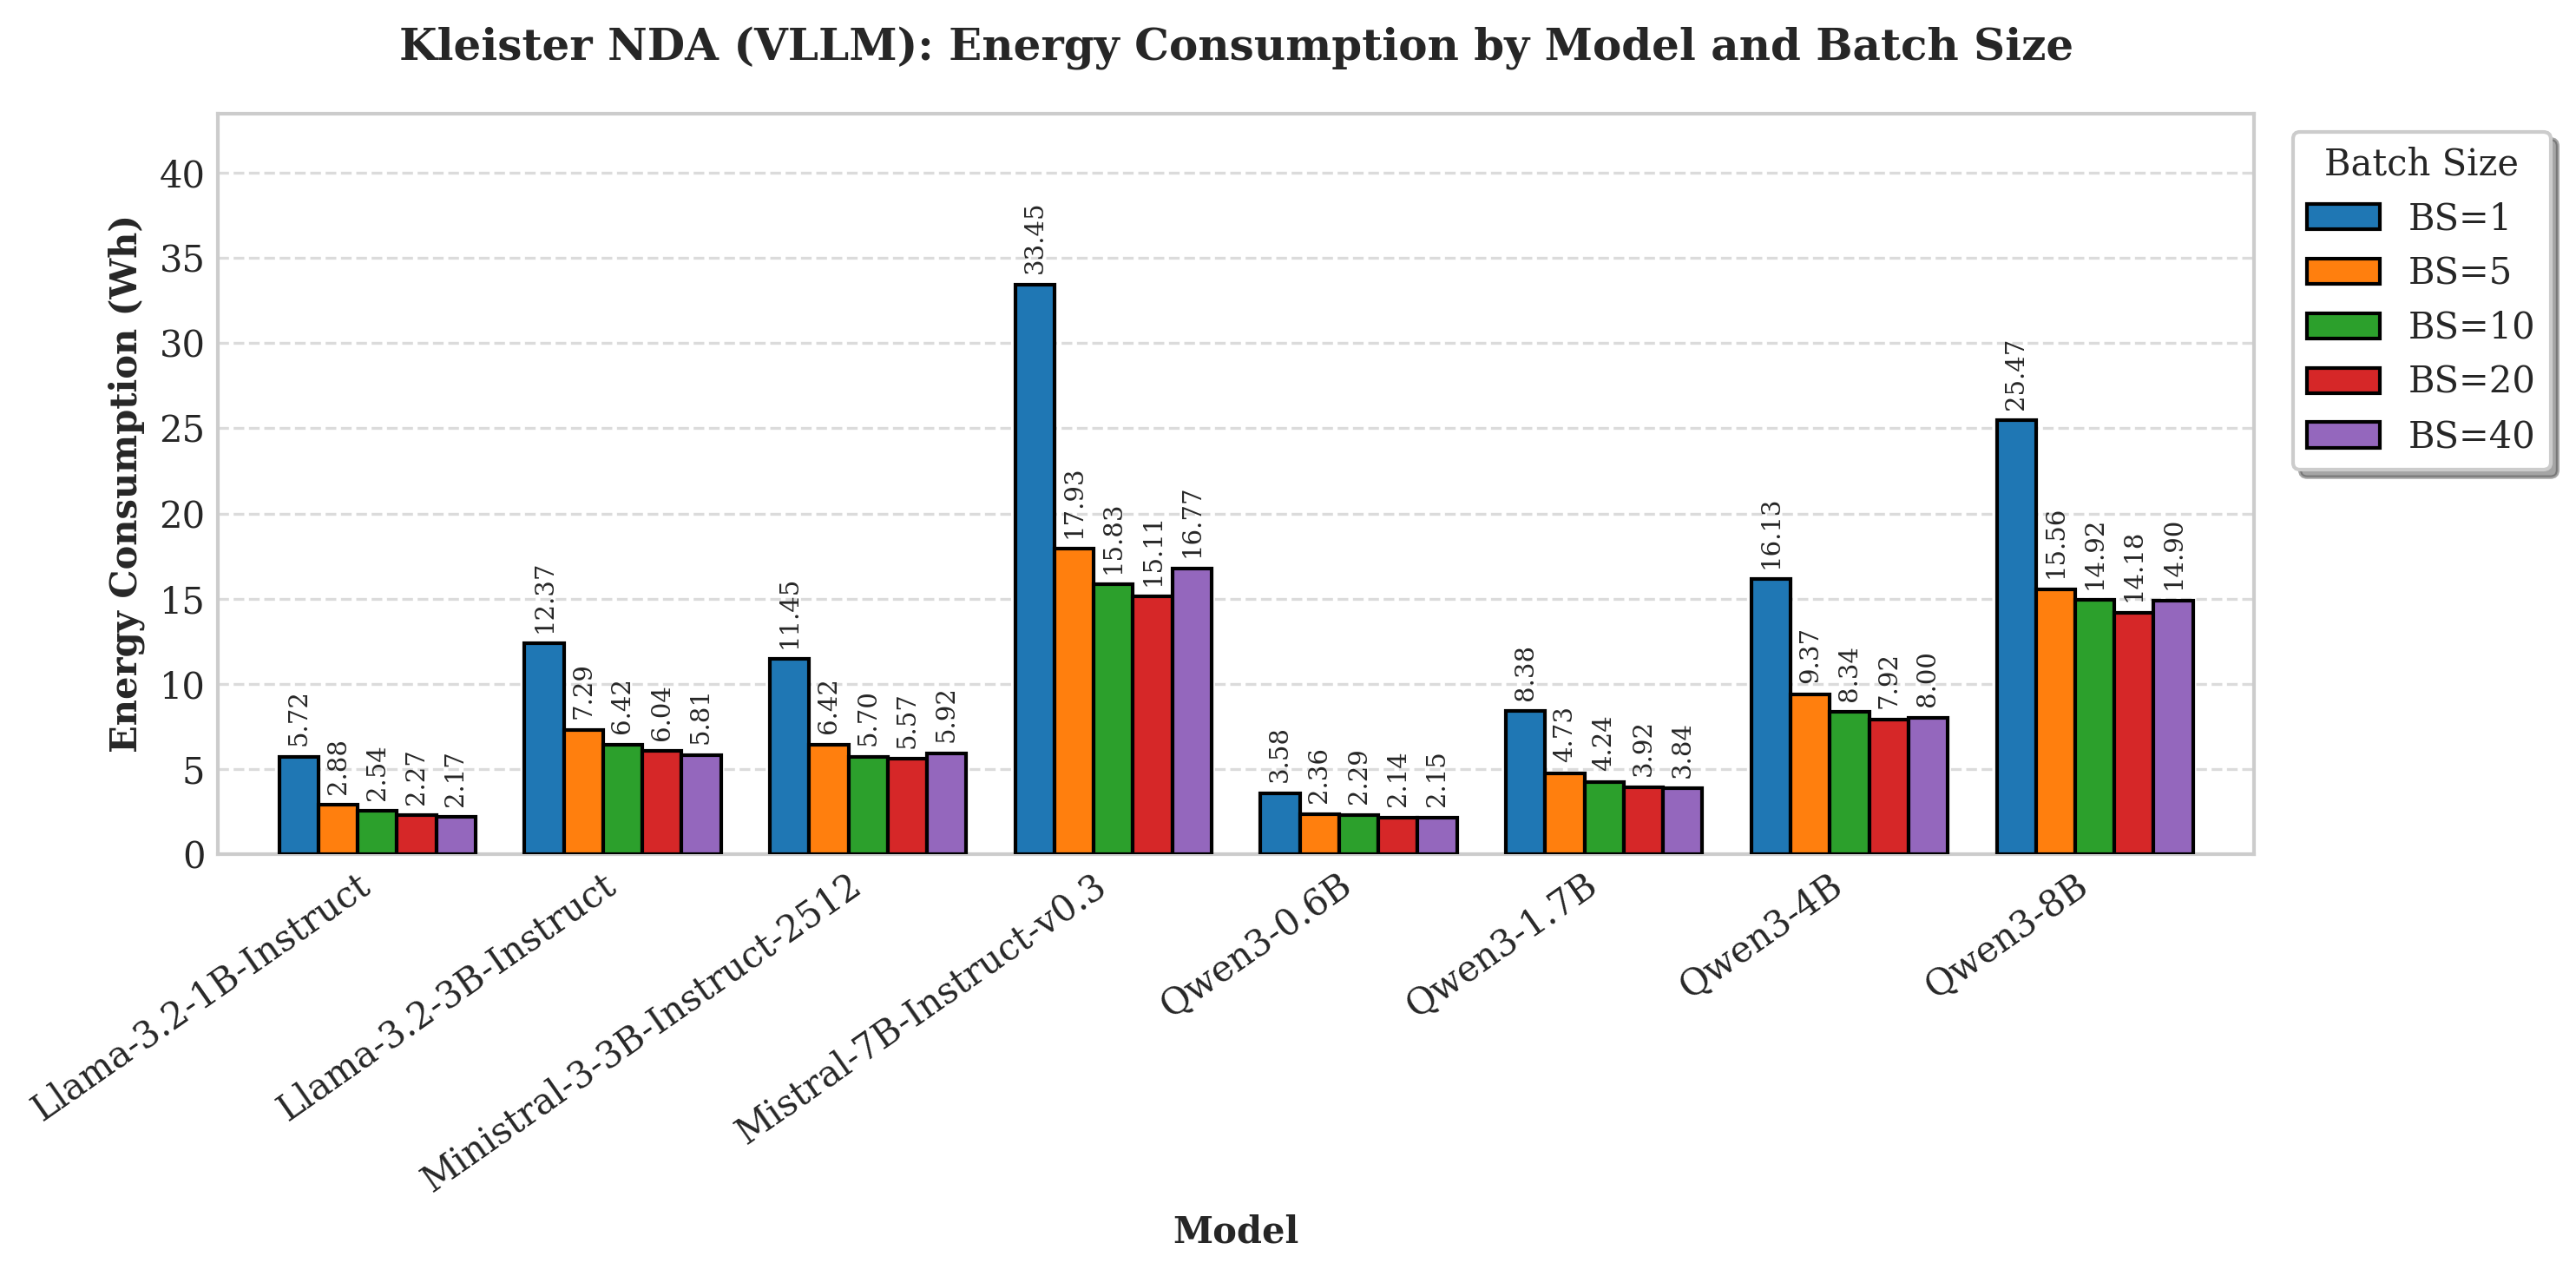

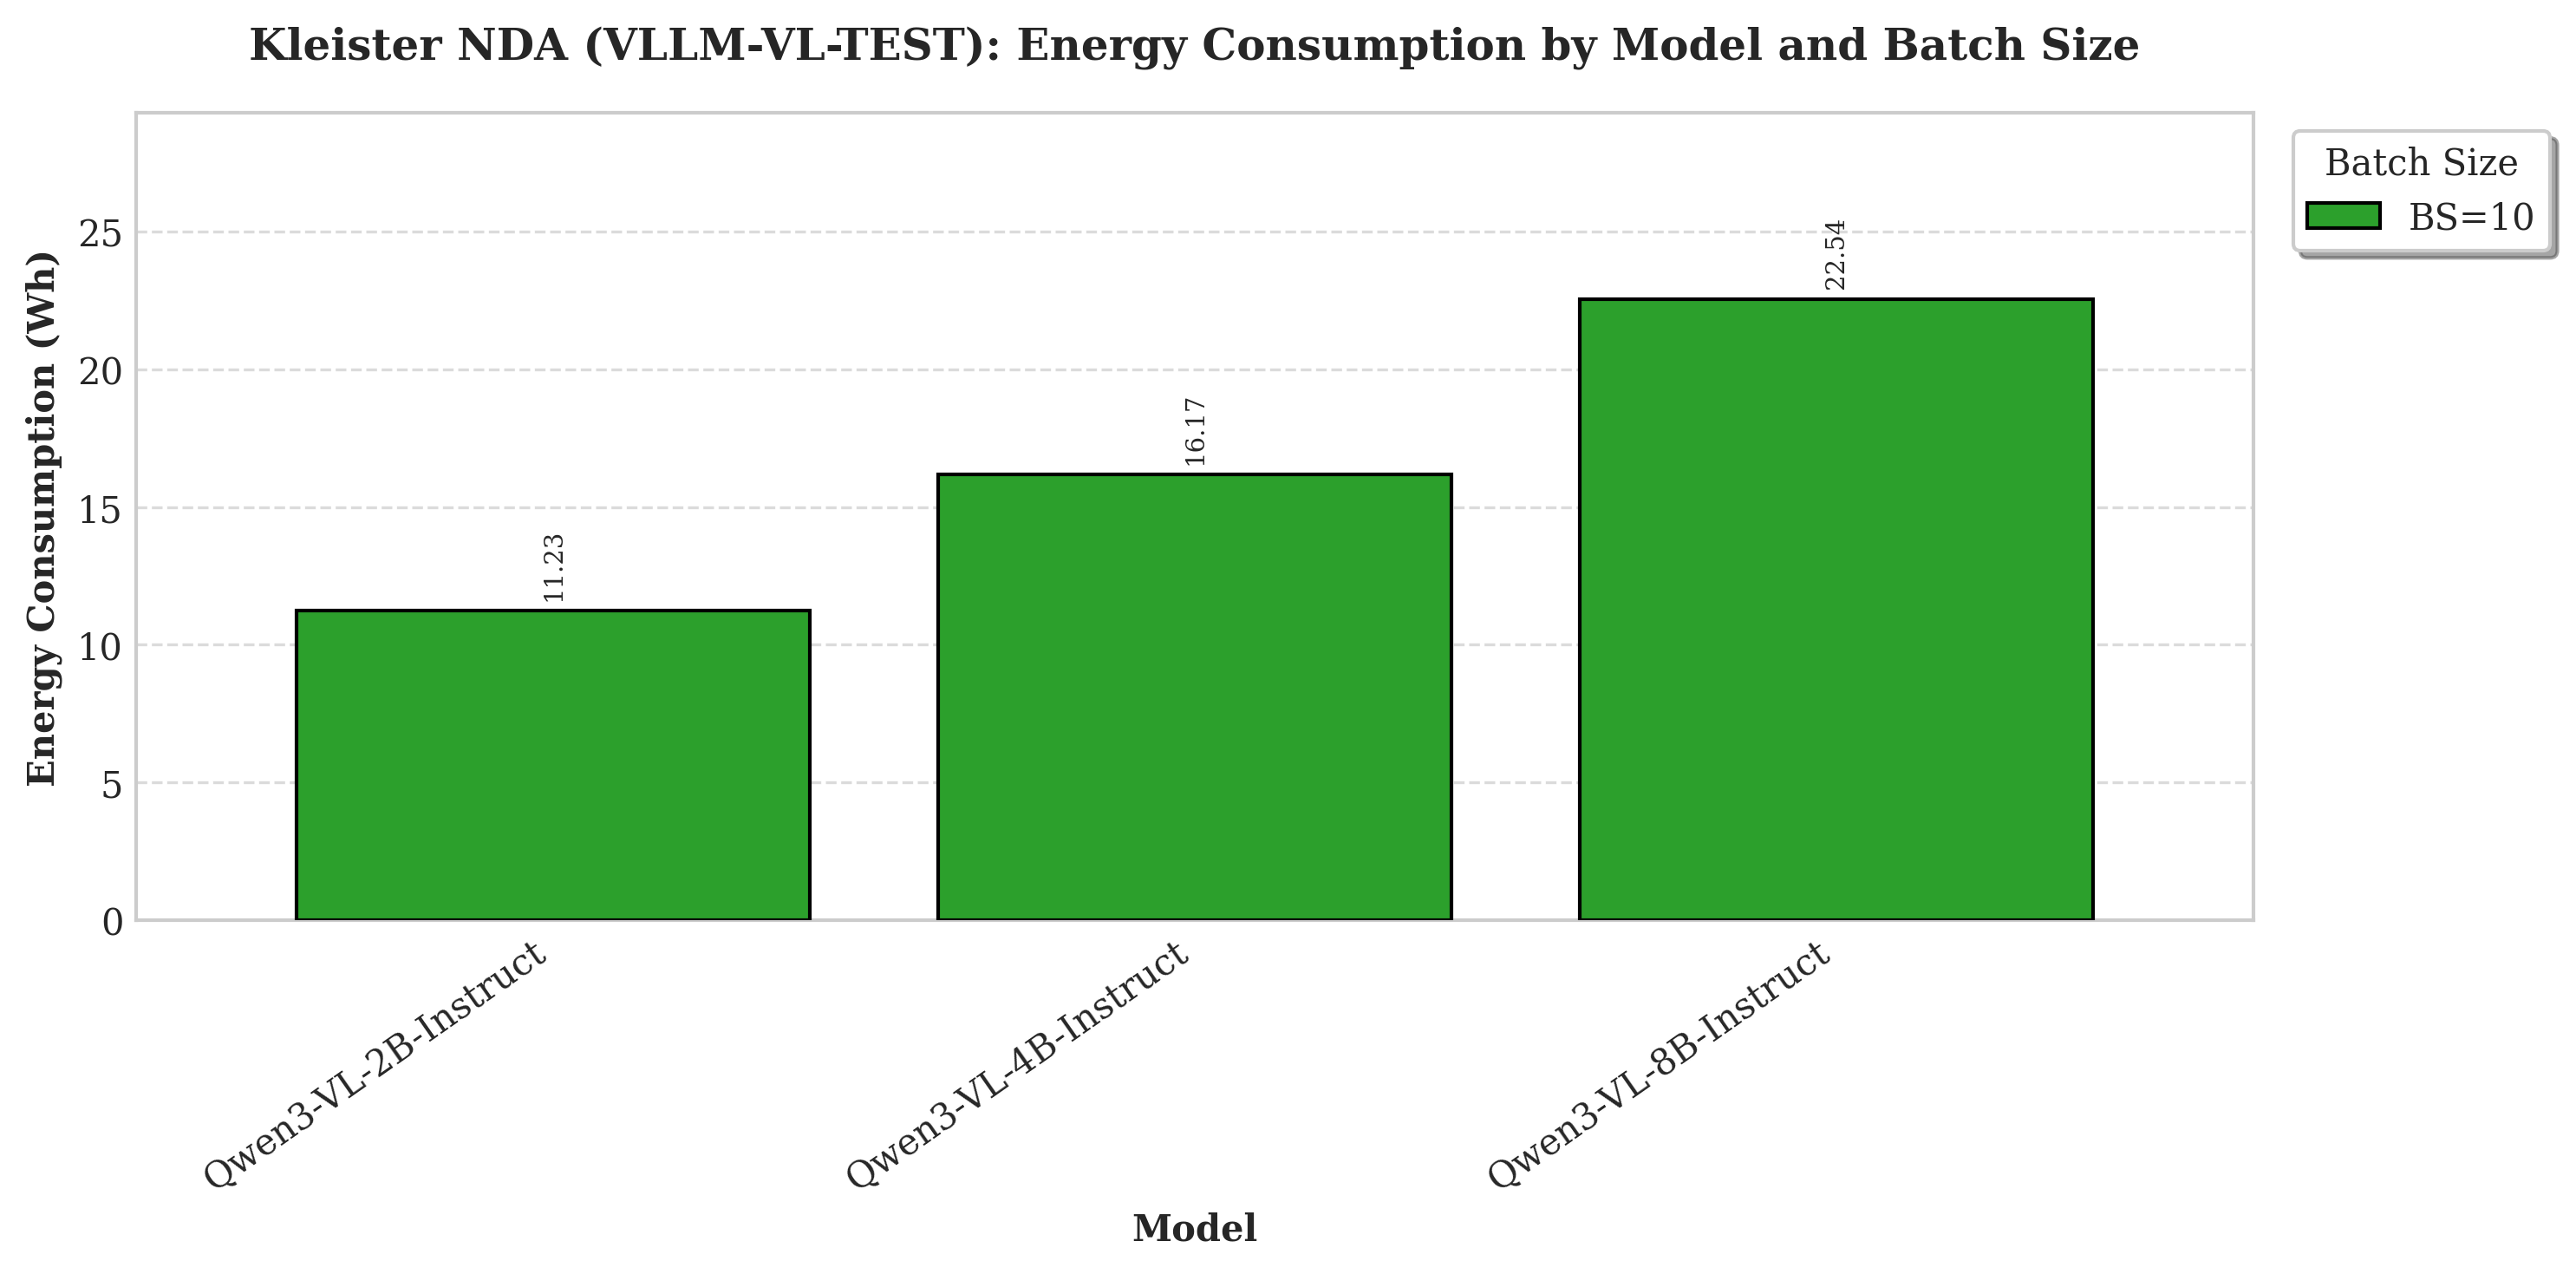

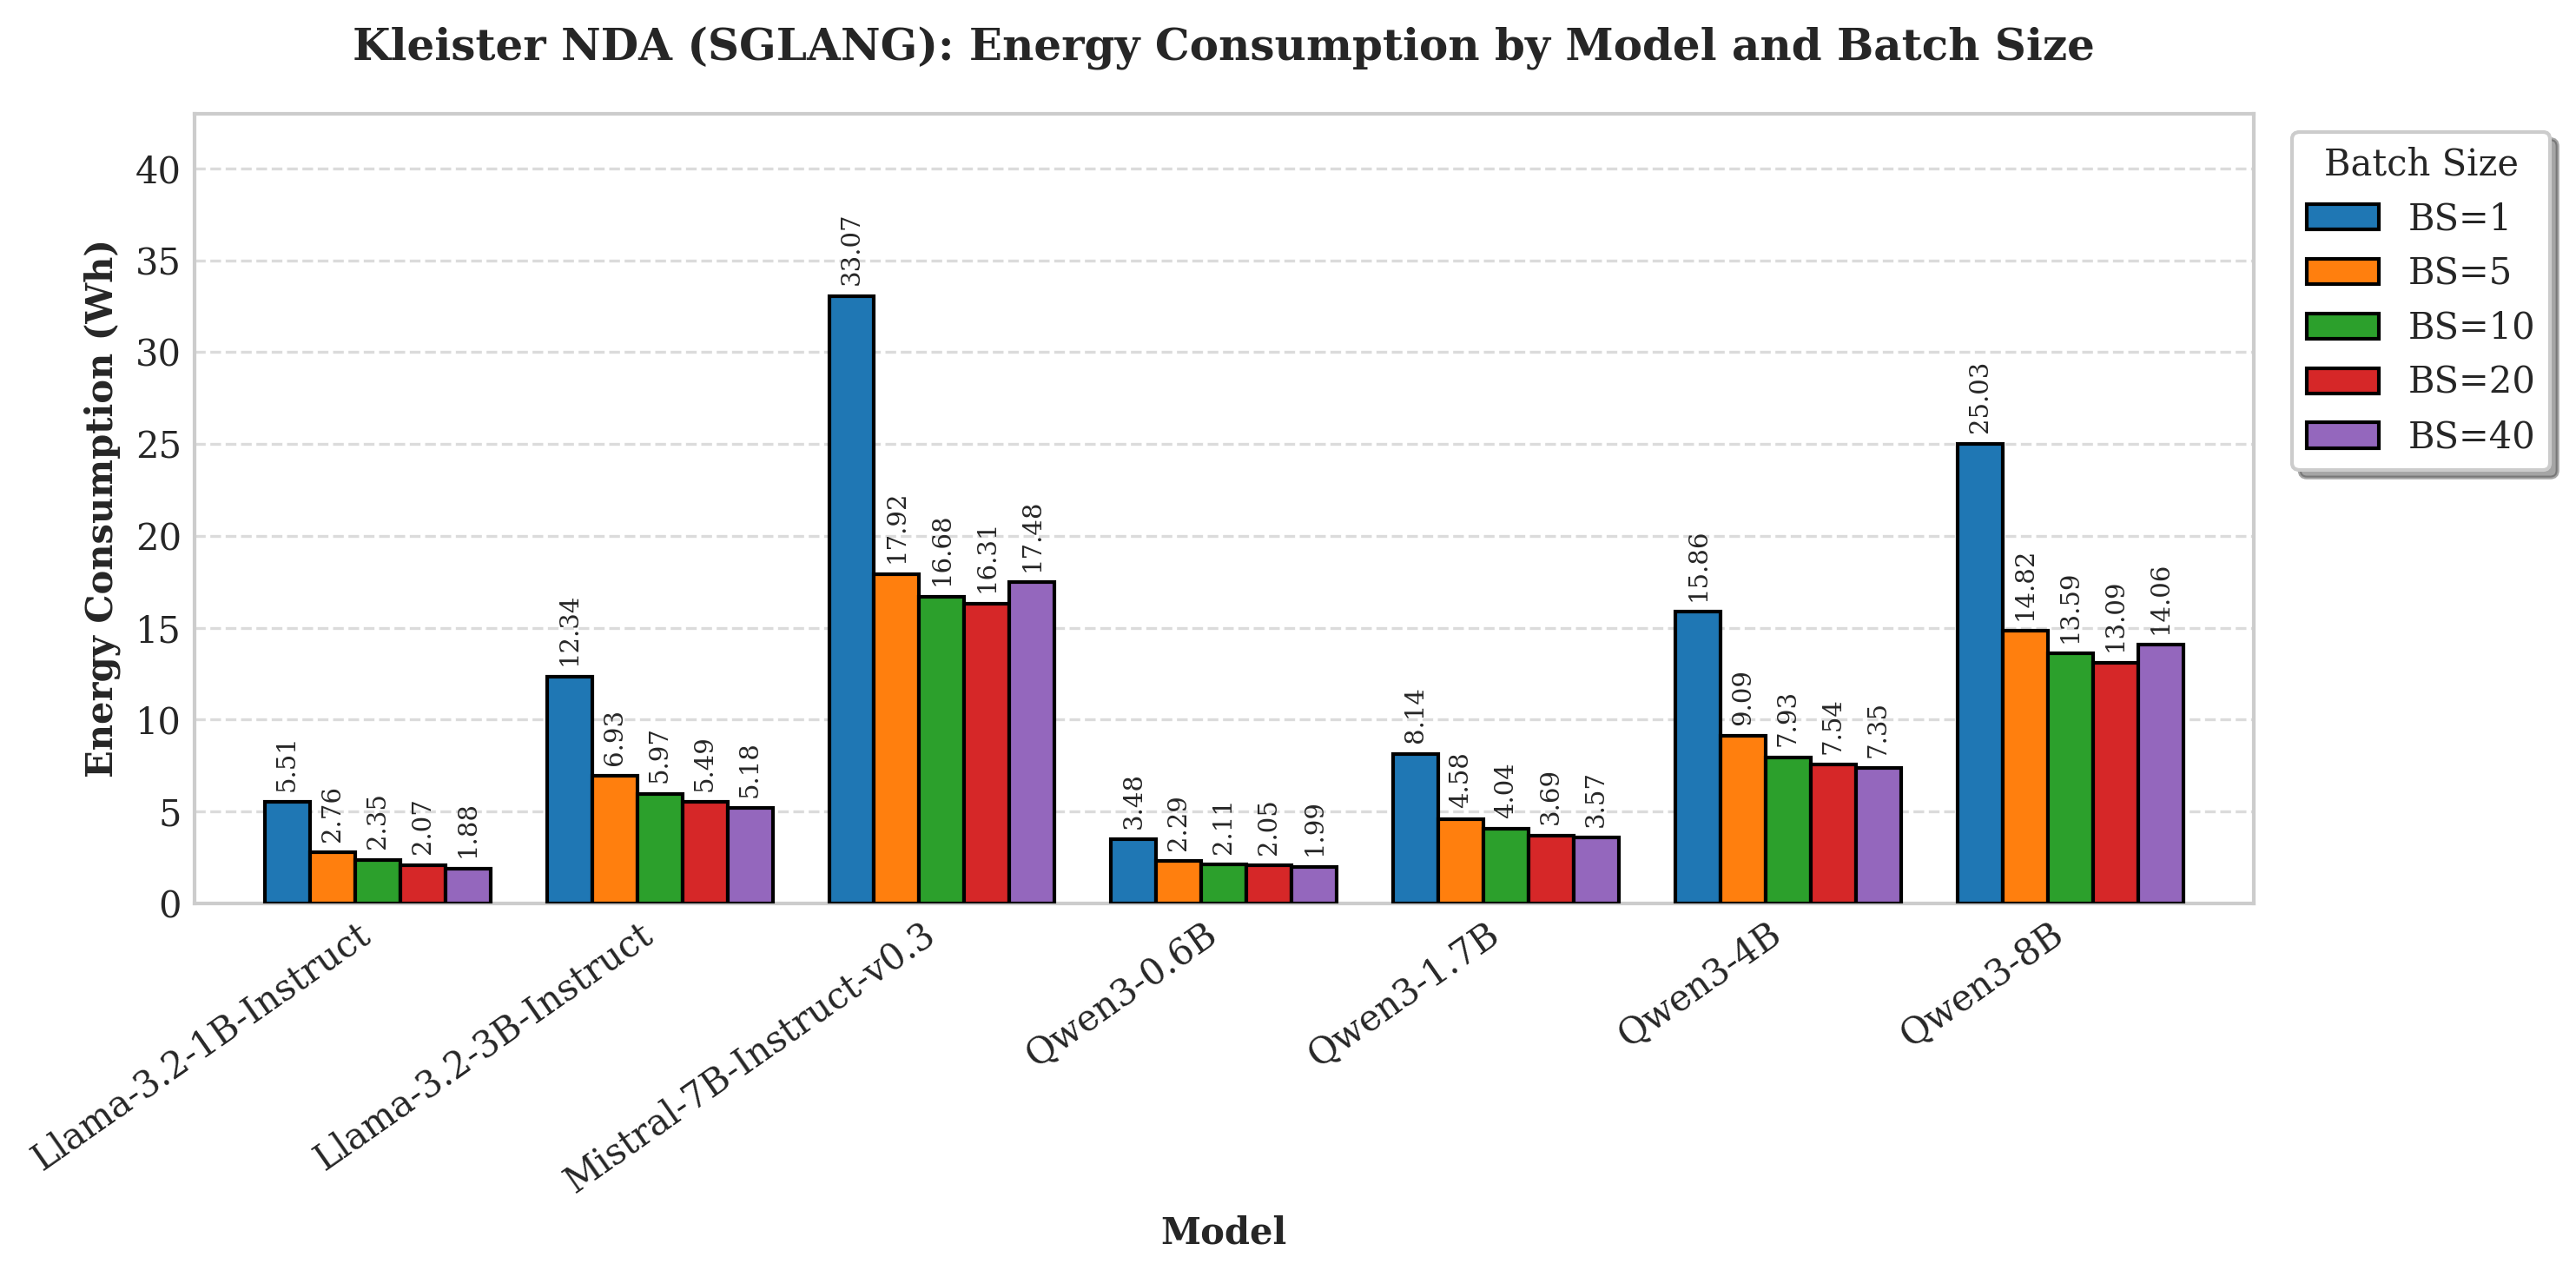

No data available for Kleister NDA with backend nan


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. General Plotting Setup
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.dpi': 300
})

datasets = ['VRDU', 'Kleister NDA']
# Identify unique backends from the dataframe
backends = df_all['Backend'].unique()

# --- NEW: Create a consistent color mapping for all possible batch sizes ---
# Find all unique batch sizes across the entire dataset to assign fixed colors
df_all['Batch_Size'] = pd.to_numeric(df_all['Batch_Size']).fillna(1)
all_unique_bs = sorted(df_all['Batch_Size'].unique())

cmap = plt.get_cmap('tab10')
# Map each batch size to a specific color from the tab10 palette
bs_color_map = {f"BS={int(bs)}": cmap(i) for i, bs in enumerate(all_unique_bs)}

# 2. Loop through datasets AND backends to generate SEPARATE plots
for dataset_name in datasets:
    for backend_name in backends:
        # Filter for current dataset AND backend
        df_filtered = df_all[(df_all['Dataset'] == dataset_name) & (df_all['Backend'] == backend_name)].copy()

        # Filter for Text-Only (DeepSeek) and Vision models
        df_text_ds = df_filtered[(df_filtered['Modality'] == 'Text-Only') & (df_filtered['Task'].astype(str).str.contains('deepseek'))].copy()
        df_vision = df_filtered[df_filtered['Modality'] == 'Vision'].copy()

        # Combine the datasets
        df_compare = pd.concat([df_text_ds, df_vision])

        if df_compare.empty:
            print(f"No data available for {dataset_name} with backend {backend_name}")
            continue

        # Group by Model and Batch Size, taking the minimum energy consumed
        df_grouped = df_compare.groupby(['Model', 'Batch_Size'])['Energy_Wh'].min().reset_index()

        # Pivot the data: Model becomes the X-axis, and Batch_Size becomes the grouped bars
        pivot_df = df_grouped.pivot(index='Model', columns='Batch_Size', values='Energy_Wh').fillna(0)

        # Sort the batch sizes numerically
        pivot_df = pivot_df.sort_index(axis=1)

        # Format the column names so the legend looks clean (e.g., "BS=1", "BS=5")
        pivot_df.columns = [f"BS={int(c)}" for c in pivot_df.columns]

        # Sort the models alphabetically
        pivot_df = pivot_df.sort_index()

        # --- NEW: Apply the fixed color mapping to the columns present in this dataset ---
        colors = [bs_color_map[col] for col in pivot_df.columns]

        # --- Create a NEW figure for the current dataset + backend ---
        fig, ax = plt.subplots(figsize=(10.0, 5.0))

        # Plot the bars with the consistent colors
        pivot_df.plot(kind='bar', color=colors, edgecolor='black', width=0.8, ax=ax, zorder=3)

        # Formatting the chart
        ax.set_title(f'{dataset_name} ({str(backend_name).upper()}): Energy Consumption by Model and Batch Size', pad=15, fontweight='bold')
        ax.set_xlabel('Model', fontweight='bold')
        ax.set_ylabel('Energy Consumption (Wh)', fontweight='bold')

        ax.set_xticklabels(pivot_df.index, rotation=35, ha='right')

        # Position the legend outside the plot
        ax.legend(title='Batch Size', loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True, shadow=True)

        ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
        ax.grid(False, axis='x')

        # Add value labels vertically on top of each bar, filtering out 0 values
        for container in ax.containers:
            labels = [f'{v.get_height():.2f}' if v.get_height() > 0 else '' for v in container]
            ax.bar_label(container, labels=labels, padding=3, rotation=90, fontsize=7)

        # Add some top margin so the tallest labels don't get cut off
        ax.margins(y=0.3)

        plt.tight_layout()

        # Save each plot with a dynamic, dataset-specific AND backend-specific filename
        clean_dataset = dataset_name.replace(" ", "_").lower()
        clean_backend = str(backend_name).replace(" ", "_").lower()
        plt.savefig(f'acl_energy_by_batch_size_{clean_dataset}_{clean_backend}.pdf', format='pdf', bbox_inches='tight')
        plt.show()

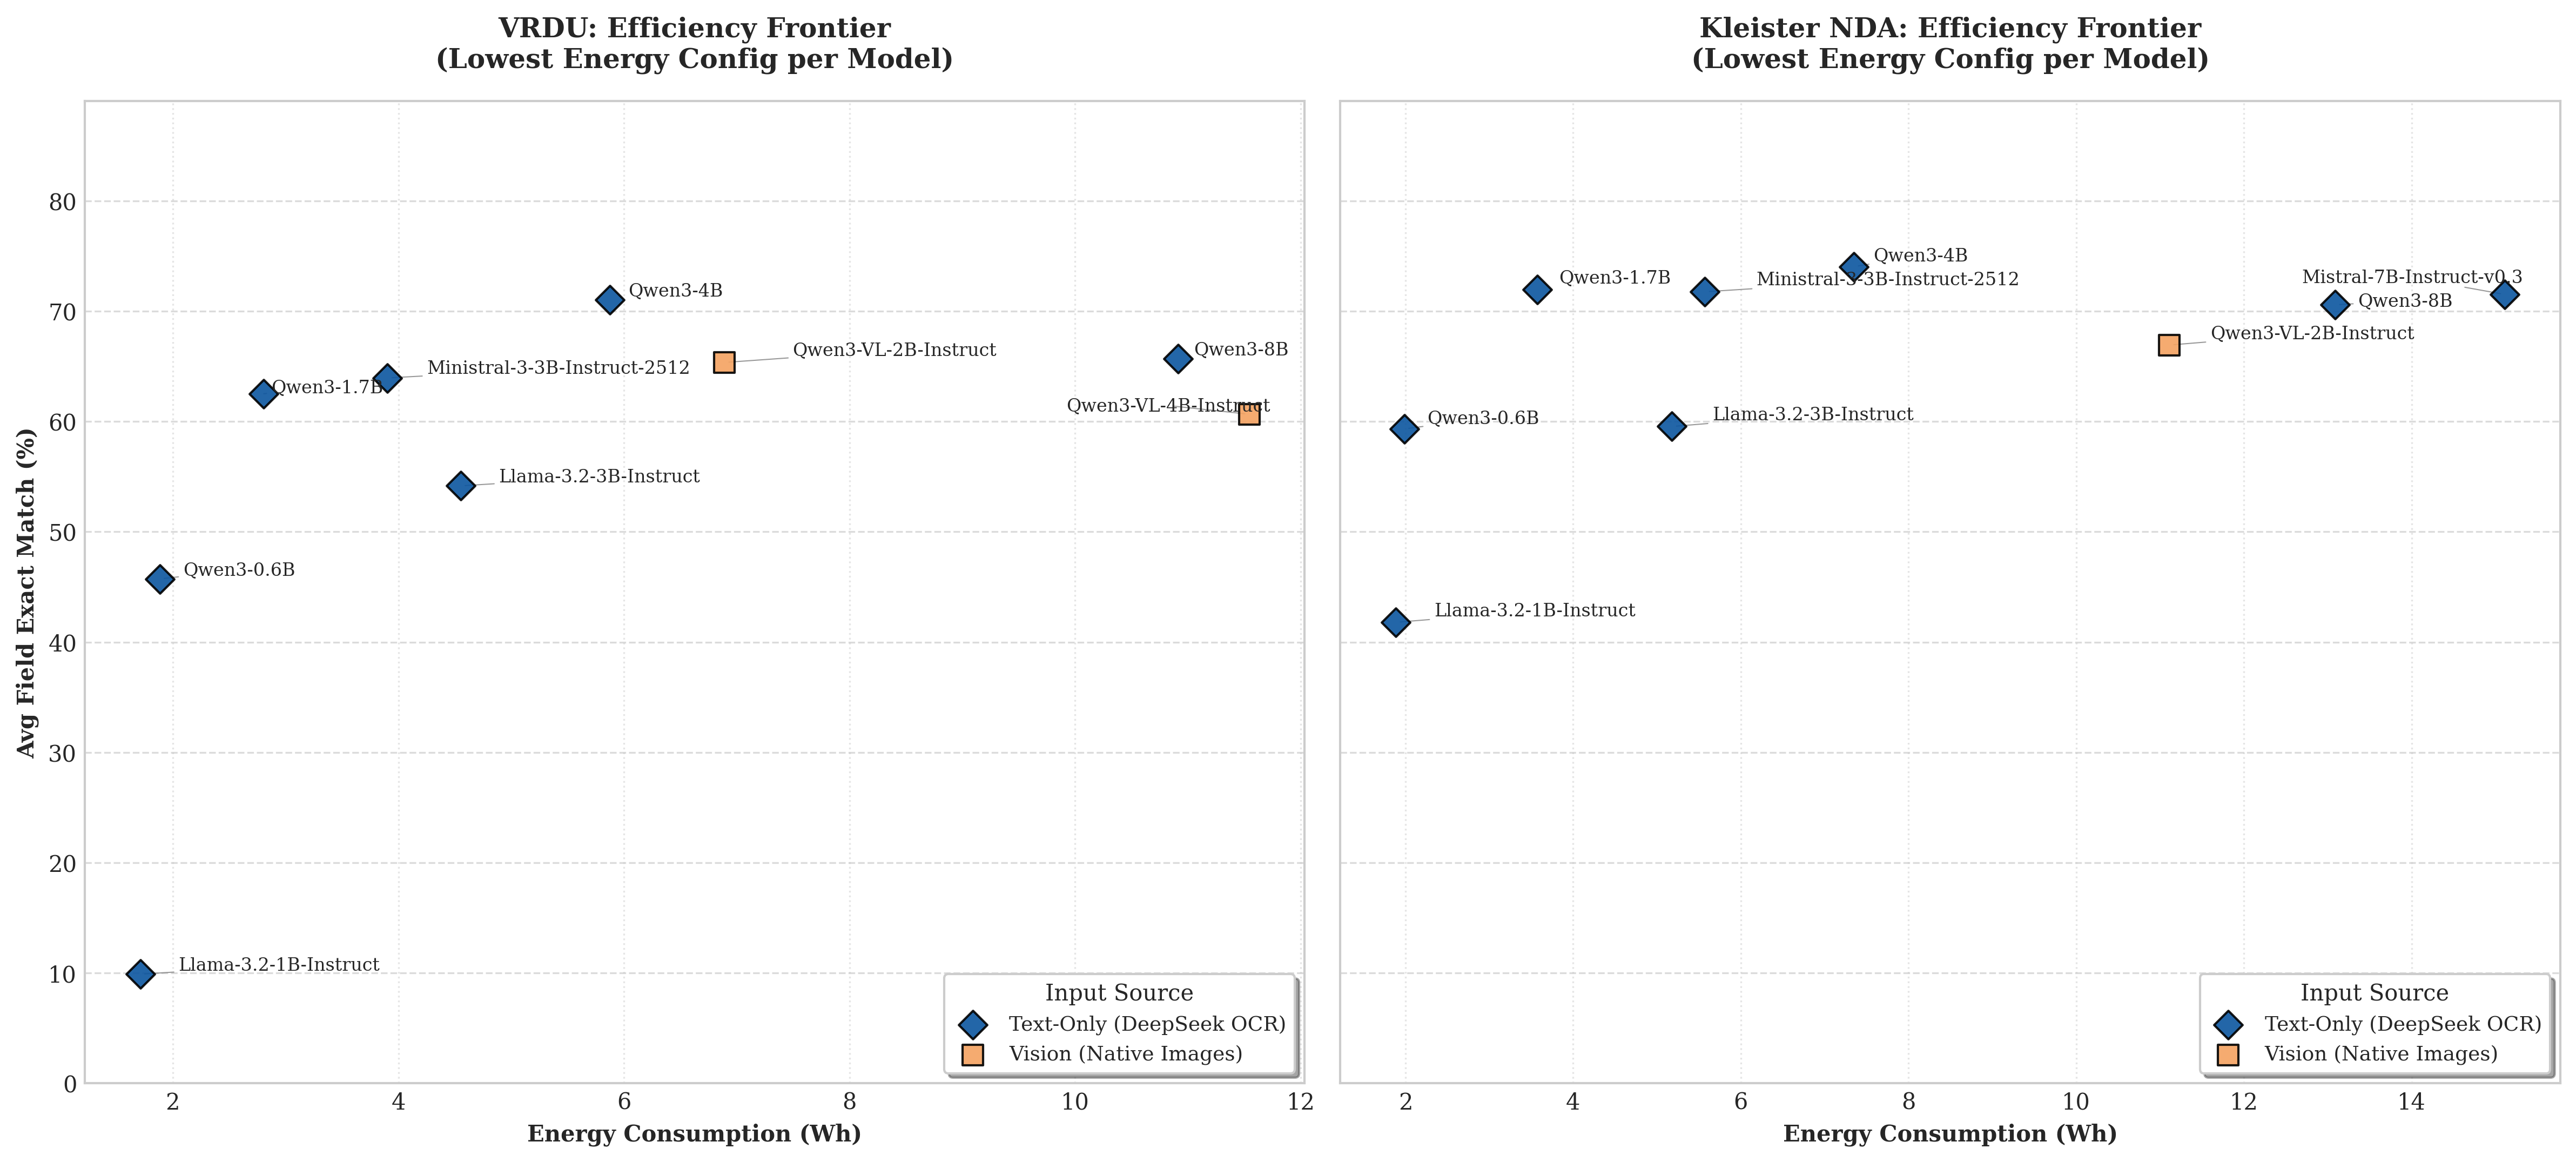

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 1. Create a clean Strategy column to differentiate the input sources
def map_strategy(row):
    if row['Modality'] == 'Vision':
        return 'Vision (Native Images)'
    elif 'deepseek' in str(row['Task']).lower():
        return 'Text-Only (DeepSeek OCR)'
    elif 'docling' in str(row['Task']).lower():
        return 'Text-Only (Docling)'
    else:
        return 'Text-Only (Baseline OCR)'

# Assuming df_all is loaded and ready
df_all['Strategy'] = df_all.apply(map_strategy, axis=1)

# Define consistent colors and distinct markers for the 2 targeted strategies
strategy_styles = {
    'Text-Only (DeepSeek OCR)': {'color': '#0b559f', 'marker': 'D'}, # Dark Blue Diamond
    'Vision (Native Images)':   {'color': '#f4a261', 'marker': 's'}  # Orange Square
}

# 2. Filter to keep ONLY the batch size with the lowest Energy_Wh per Model + Strategy
# idxmin() finds the row index where Energy_Wh is lowest for each group
idx = df_all.groupby(['Dataset', 'Model', 'Strategy'])['Energy_Wh'].idxmin()
df_lowest_energy = df_all.loc[idx].copy()

# Filter down to just Vision and DeepSeek OCR
df_lowest_energy = df_lowest_energy[df_lowest_energy['Strategy'].isin(strategy_styles.keys())]

# Find the absolute highest accuracy across ALL datasets for the remaining models
global_max_acc = df_lowest_energy['Accuracy'].max()

# 3. Plotting Setup (1 row, 2 columns)
plt.style.use('seaborn-v0_8-whitegrid')

# Automatically calculate height based on width for a consistent ratio
fig_width = 16.0
fig_height = fig_width / 2.2

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.figsize': (fig_width, fig_height),
    'figure.dpi': 300
})

# Keep sharey=True so the plots are strictly visually comparable
fig, axes = plt.subplots(1, 2, sharey=True)
datasets = ['VRDU', 'Kleister NDA']

for i, dataset_name in enumerate(datasets):
    ax = axes[i]
    df_ds = df_lowest_energy[df_lowest_energy['Dataset'] == dataset_name].copy()

    if df_ds.empty:
        ax.set_title(f'{dataset_name} (No Data)', fontweight='bold')
        continue

    texts = []

    # Plot each strategy one by one
    for strategy in strategy_styles.keys():
        subset = df_ds[df_ds['Strategy'] == strategy].copy()
        if subset.empty:
            continue

        # Sort by energy to ensure consistent ordering in the dataframe
        subset = subset.sort_values('Energy_Wh').reset_index(drop=True)
        style = strategy_styles[strategy]

        # Scatter plot for the points (No frontier line logic needed anymore)
        ax.scatter(subset['Energy_Wh'], subset['Accuracy'],
                   s=80, c=style['color'], marker=style['marker'],
                   edgecolors='black', linewidths=1, alpha=0.9, zorder=4, label=strategy)

        # Prepare annotations (Model name)
        for _, row in subset.iterrows():
            label = f"{row['Model']}"
            texts.append(ax.text(row['Energy_Wh'], row['Accuracy'], label, fontsize=8, zorder=5))

    # Adjust text to prevent overlap
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.8), ax=ax)

    # Formatting
    ax.set_xscale('linear')
    ax.set_title(f'{dataset_name}: Efficiency Frontier\n(Lowest Energy Config per Model)', pad=15, fontweight='bold')
    ax.set_xlabel('Energy Consumption (Wh)', fontweight='bold')

    # Explicitly set the shared Y-axis from 0 to the global max + a 15% buffer
    ax.set_ylim(0, global_max_acc + 15)

    if i == 0:
        ax.set_ylabel('Avg Field Exact Match (%)', fontweight='bold')

    # Legend handling
    ax.legend(loc='lower right', frameon=True, shadow=True, fontsize=9, title="Input Source")
    ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
    ax.grid(True, axis='x', linestyle=':', alpha=0.5, zorder=0)

plt.tight_layout()
# Updated filename so you don't accidentally overwrite your original 4-source plot!
plt.savefig('acl_efficiency_frontier_vision_deepseek.pdf', format='pdf', bbox_inches='tight')
plt.show()